#We derived an objective, data-driven weighting scheme for the ND-GAIN indicators using PCA. The resulting index is highly consistent with the official ND-GAIN Index while avoiding predefined expert weights.

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import zscore


In [4]:
df = pd.read_csv("../data/data_preprocessed/processed_data.csv")
df = df.set_index(["Country", "Year"])


In [5]:
indicator_cols = [
    "Capacity",
    "Economic",
    "Ecosystems",
    "Exposure",
    "Food",
    "Governance",
    "Habitat",
    "Health",
    "Infrastructure",
    "Sensitivity",
    "Social",
    "Water",
]

In [6]:
df["Economic"] = 1 - df["Economic"]
df["Governance"] = 1 - df["Governance"]
df["Social"] = 1 - df["Social"]

In [7]:
X = df[indicator_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
X

Capacity  Economic  Ecosystems  Exposure      Food  Governance  \
Country Year                                                                   
AFG     1995  0.893281  0.503503    0.515884  0.480512  0.665745    0.871910   
        1996  0.893892  0.503503    0.516995  0.480512  0.665583    0.871910   
        1997  0.894459  0.503503    0.518030  0.480512  0.665420    0.858608   
        1998  0.890161  0.503503    0.518156  0.480512  0.657103    0.845306   
        1999  0.885896  0.503503    0.518156  0.480512  0.648959    0.856311   
...                ...       ...         ...       ...       ...         ...   
ZWE     2019  0.597433  0.749337    0.515729  0.516912  0.544129    0.871595   
        2020  0.591558  0.739735    0.515480  0.516912  0.571499    0.875838   
        2021  0.596365  0.739735    0.515921  0.516912  0.560939    0.868562   
        2022  0.583779  0.739735    0.513962  0.516912  0.557942    0.864612   
        2023  0.573759  0.739735    0.513962  0.516912  0.559073    0.864899   

               Habitat    Health  Infrastructure  Sensitivity    Social  \
Country Year                                                              
AFG     1995  0.602933  0.748302        0.355586     0.419587  0.700042   
        1996  0.604235  0.748302        0.354484     0.419307  0.700046   
        1997  0.605583  0.748302        0.353925     0.419055  0.700048   
        1998  0.606909  0.748302        0.353710     0.418794  0.700051   
        1999  0.608137  0.748302        0.352292     0.419433  0.700053   
...                ...       ...             ...          ...       ...   
ZWE     2019  0.571407  0.699729        0.320293     0.419507  0.868528   
        2020  0.564062  0.699319        0.305472     0.432905  0.866914   
        2021  0.556834  0.700294        0.306890     0.420585  0.860463   
        2022  0.549853  0.699798        0.299974     0.424039  0.859696   
        2023  0.548898  0.699798        0.275926     0.424127  0.858760   

                 Water  
Country Year            
AFG     1995  0.529692  
        1996  0.528281  
        1997  0.526853  
        1998  0.525424  
        1999  0.525585  
...                ...  
ZWE     2019  0.383647  
        2020  0.391679  
        2021  0.391842  
        2022  0.391776  
        2023  0.391776  

[5394 rows x 12 columns]

In [9]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [10]:

explained = pd.DataFrame({
    "PC": [f"PC{i+1}" for i in range(len(indicator_cols))],
    "Explained Variance": pca.explained_variance_ratio_,
    "Cumulative": pca.explained_variance_ratio_.cumsum()
})

explained


,PC,Explained Variance,Cumulative
0,PC1,0.506185,0.506185
1,PC2,0.114925,0.621110
2,PC3,0.089599,0.710709
3,PC4,0.070765,0.781474
4,PC5,0.055399,0.836874
5,PC6,0.039356,0.876230
6,PC7,0.035871,0.912102
7,PC8,0.030772,0.942874
8,PC9,0.025706,0.968580
9,PC10,0.018904,0.987483


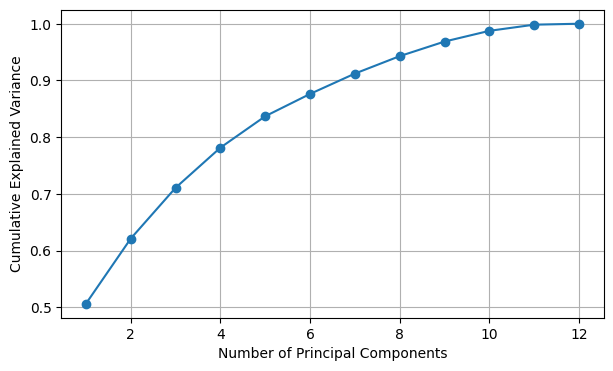

In [11]:

plt.figure(figsize=(7,4))
plt.plot(
    range(1, len(indicator_cols)+1),
    explained["Cumulative"],
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid(True)
plt.show()

In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=indicator_cols,
    columns=[f"PC{i+1}" for i in range(len(indicator_cols))]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Capacity,0.380948,-0.041794,-0.010682,0.052996,-0.000411,0.007953,-0.251873,-0.138551,0.094122,0.525497,0.192726,0.667353
Economic,0.255446,-0.303804,0.096503,0.430889,-0.448474,-0.183391,0.516257,-0.010493,-0.371507,0.085490,-0.025350,-0.010541
Ecosystems,0.296086,0.013394,-0.126795,-0.386966,0.484670,0.185470,0.391958,0.232389,-0.347663,0.339406,0.045913,-0.176694
Exposure,0.234249,0.315270,-0.508010,-0.340421,-0.227413,-0.387415,0.168736,0.098005,-0.012321,-0.362460,-0.085075,0.305158
Food,0.362303,0.004960,0.004253,-0.006036,0.135231,-0.312991,-0.116501,-0.435150,0.173802,0.180999,-0.616997,-0.325310
Governance,0.297012,-0.349295,0.208432,-0.080214,0.053161,0.002601,0.271222,0.358148,0.713038,-0.160955,0.026915,0.013413
Habitat,0.263251,-0.191761,-0.404294,-0.076830,-0.438213,0.624323,-0.264802,0.071767,0.010485,-0.000410,-0.146577,-0.214230
Health,0.371920,-0.000435,-0.047215,0.005851,0.067577,-0.069772,-0.069668,-0.435649,0.021672,-0.258000,0.692691,-0.329361
Infrastructure,0.117250,0.653839,-0.161824,0.522513,-0.003305,0.055502,0.090485,0.274934,0.257412,0.227455,0.082587,-0.218761
Sensitivity,0.283545,0.322207,0.382277,0.096439,0.135821,0.474881,0.160320,-0.218168,-0.119334,-0.434901,-0.232329,0.292802


In [13]:
pca = PCA(n_components=1)

pcs = pca.fit_transform(X_scaled)

pc_df = pd.DataFrame(
    pcs,
    index=df.index,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/deniz/.pyenv/versions/3.10.6/envs/climate-resilience-dashboard/lib/python3.10/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


In [14]:
pc_df

PC1
Country Year          
AFG     1995  3.168821
        1996  3.172747
        1997  3.159407
        1998  3.112326
        1999  3.101828
...                ...
ZWE     2019  2.651805
        2020  2.713049
        2021  2.619145
        2022  2.555097
        2023  2.510351

[5394 rows x 1 columns]

In [15]:
pc_df.describe()

,PC1
count,5.394000e+03
mean,2.107654e-17
std,2.464823e+00
min,-5.950993e+00
25%,-1.685913e+00
50%,-4.781942e-02
75%,1.971663e+00
max,5.387487e+00


In [16]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["ResilienceScore"] = scaler.fit_transform(pc_df[["PC1"]])

In [19]:
# Load original ND-GAIN data
df_original = pd.read_csv("../data/inputs/fetch/ndgain_raw.csv")

COLUMN_MAP = {
    "REF_AREA": "Country",
    "TIME_PERIOD": "Year",
    "INDICATOR": "Indicator",
    "OBS_VALUE": "Value",
}


df_original = df_original.rename(columns=COLUMN_MAP)

df_original["Year"] = pd.to_numeric(df_original["Year"], errors="coerce").astype("Int64")
df_original["Value"] = pd.to_numeric(df_original["Value"], errors="coerce")

df_original = df_original.drop_duplicates(
        subset=["Country", "Year", "Indicator"]
    )

df_original = df_original.sort_values(
        ["Country", "Indicator", "Year"]
    ).set_index(["Country", "Year"])


/var/folders/_c/c3v4ck6n4gv2qm_3_ttzkcp00000gn/T/ipykernel_29250/2190409527.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df_original = pd.read_csv("../data/inputs/fetch/ndgain_raw.csv")


In [20]:
df_original = df_original[df_original['Indicator']=='NDGAIN_OVRL']


In [21]:
df_original["Value"].corr(pc_df["PC1"])

np.float64(-0.9642928735534896)

To construct a composite **climate risk** score, the ND-GAIN indicators were first oriented so that higher values consistently represented higher climate risk. The vulnerability indicators (Exposure, Sensitivity, and Capacity) were retained in their original direction, as they already reflected increasing vulnerability with higher values. The readiness indicators (Economic, Governance, and Social) were multiplied by **−1**, reversing their direction so that lower readiness corresponded to higher risk.

Principal Component Analysis (PCA) was then applied to the standardized indicators. The first principal component (PC1) explained **50.6%** of the total variance, with all indicator loadings having the same sign, indicating that PC1 captured a common underlying dimension of climate risk across the indicators.

To validate the PCA-derived composite risk score, it was compared with the official ND-GAIN Index. The resulting Pearson correlation coefficient was **−0.964**, indicating an almost perfect inverse relationship. This strong negative correlation is expected because the official ND-GAIN Index is a **resilience** measure, where higher values indicate greater readiness and lower vulnerability, whereas the PCA-derived score was intentionally constructed as a **risk** measure, where higher values indicate greater climate risk. Thus, countries with high ND-GAIN scores (high resilience) receive low PCA risk scores, and vice versa. This result demonstrates that the PCA-derived weighting scheme produces a data-driven composite risk index that is highly consistent with the underlying information captured by the official ND-GAIN methodology while aligning with the study's objective of quantifying climate risk rather than resilience.


In [22]:
comparison = pd.concat(
    [df_original["Value"], pc_df["PC1"]],
    axis=1
).rename(columns={"PC1": "RiskScore"})

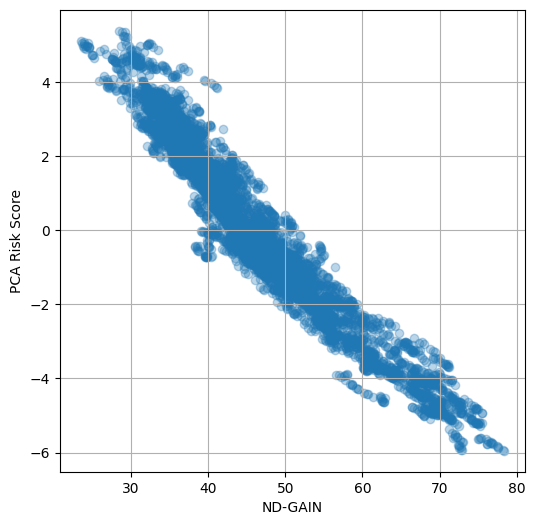

In [23]:
plt.figure(figsize=(6,6))
plt.scatter(comparison["Value"], comparison["RiskScore"], alpha=0.3)

plt.xlabel("ND-GAIN")
plt.ylabel("PCA Risk Score")
plt.grid(True)

In [24]:
comparison["ND_z"] = StandardScaler().fit_transform(comparison[["Value"]])
comparison["PC1_z"] = StandardScaler().fit_transform(comparison[["RiskScore"]])

In [25]:
trend = (
    comparison.reset_index()
              .groupby("Year")[["ND_z", "PC1_z"]]
              .mean()
)

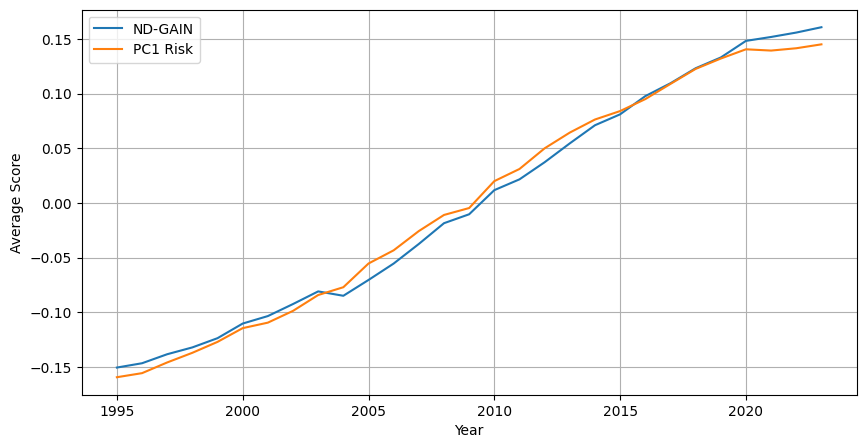

In [26]:
plt.figure(figsize=(10,5))
plt.plot(trend.index, trend["ND_z"], label="ND-GAIN")
plt.plot(trend.index, -trend["PC1_z"], label="PC1 Risk")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Average Score")
plt.grid(True)
plt.show()

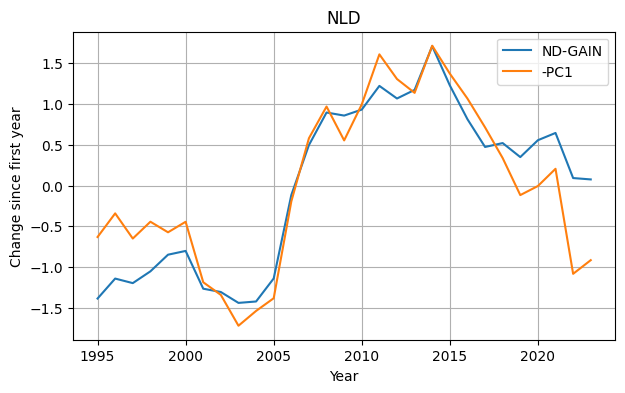

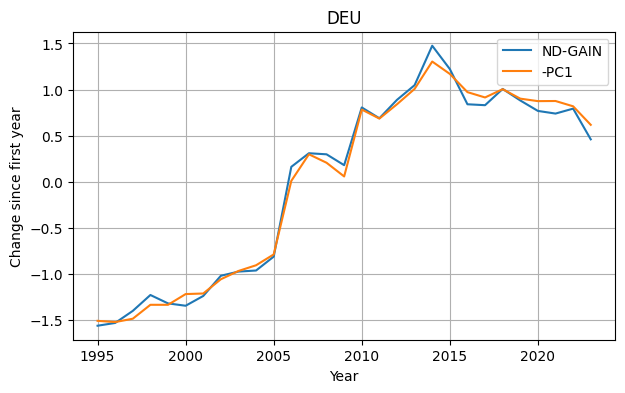

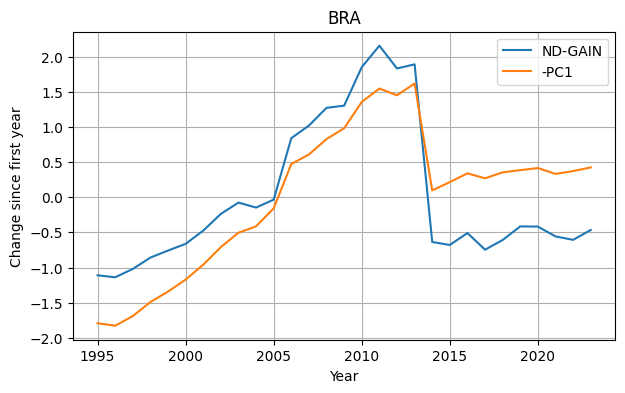

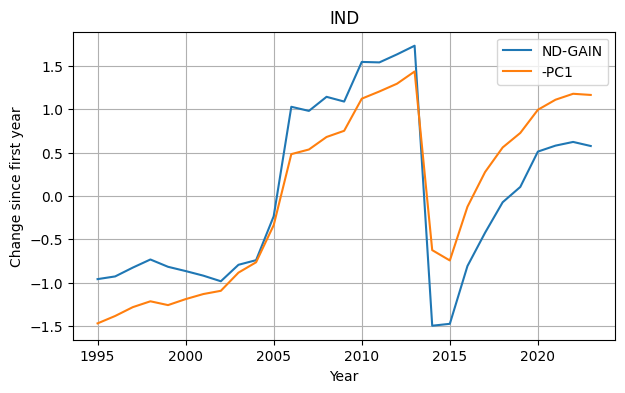

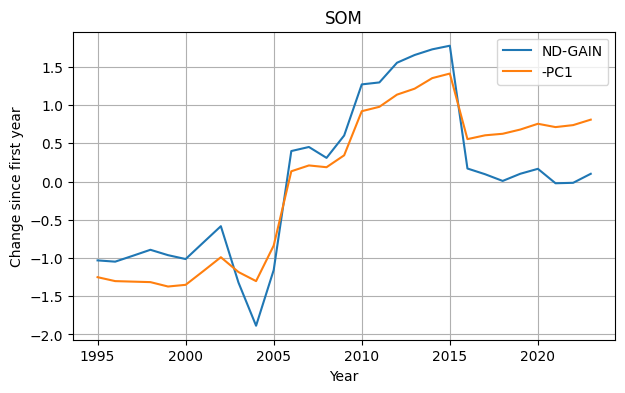

In [27]:
countries = ["NLD", "DEU", "BRA", "IND", "SOM"]

for country in countries:
    temp = (
        comparison.xs(country, level="Country")
                  .sort_index()
                  .copy()
    )

    temp["ND_std"] = zscore(temp["Value"])
    temp["PC1_std"] = zscore(temp["RiskScore"])

    plt.figure(figsize=(7,4))
    plt.plot(temp.index, temp["ND_std"], label="ND-GAIN")
    plt.plot(temp.index, -temp["PC1_std"], label="-PC1")
    plt.title(country)
    plt.xlabel("Year")
    plt.ylabel("Change since first year")
    plt.grid(True)
    plt.legend()
    plt.show()

In [28]:
countries = ["NLD", "DEU", "BRA", "IND", "SOM"]

for country in countries:
    temp = comparison.xs(country, level="Country")

    r = temp["Value"].corr(-temp["RiskScore"])

    print(f"{country}: {r:.3f}")

NLD: 0.899
DEU: 0.996
BRA: 0.785
IND: 0.883
SOM: 0.903
